<center>
<img src="https://supportvectors.ai/logo-poster-transparent.png" width="400px" style="opacity:0.7">
</center>

In [1]:
%run supportvectors-common.ipynb


<div style="color:#aaa;font-size:8pt">
<hr/>
&copy; SupportVectors AI Lab. <blockquote>This notebook is part of the AI Lab Book companion repository. 
Code is released under the MIT License and accompanying text under CC BY 4.0 - see the LICENSE files at the repository root.

 </blockquote>
 <hr/>
</div>



In [2]:
from openai import OpenAI
import base64

## Vision-language prompting with Qwen3-VL

We send an image plus a question in one chat call. `Qwen/Qwen3-VL-8B-Instruct` on the SupportVectors cluster is multimodal: it accepts `image_url` content parts directly.

In [3]:
import os

# SupportVectors cluster (WireGuard required). .env sets
# OPENAI_BASE_URL=http://10.0.10.70:8000/v1 and a dummy OPENAI_API_KEY.
client = OpenAI(
    base_url=os.environ["OPENAI_BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
)

In [ ]:
model_name = "Qwen/Qwen3-VL-8B-Instruct"

In [5]:
IMAGE_PATH = "../../images/phys_img.jpeg"

# ---- helper ----
def image_to_base64(path: str) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

image_b64 = image_to_base64(IMAGE_PATH)


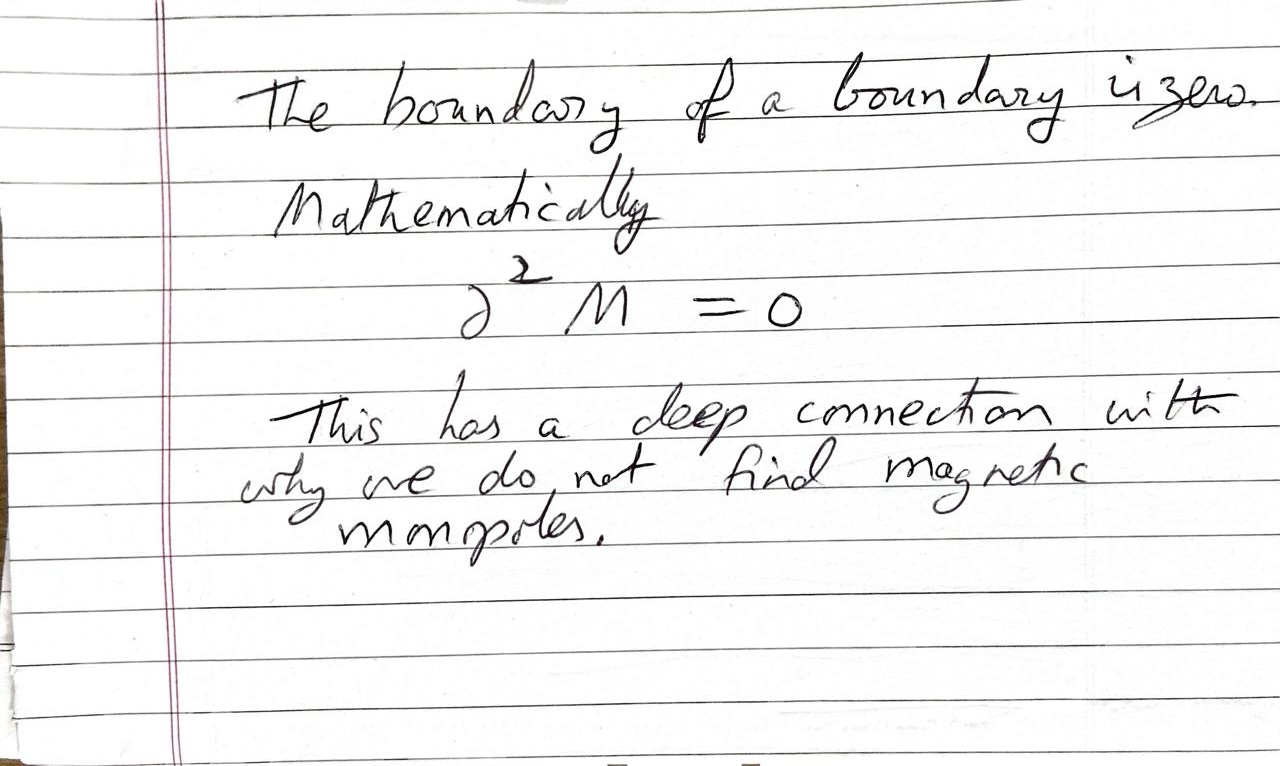

In [6]:
from IPython.display import Image, display

display(Image(filename=IMAGE_PATH))


In [8]:
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": '''I am a physics student and came across this notes.  
                Can you explain it?  Put this explanation as a tutorial in a latex document.'''},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{image_b64}"
                    },
                },
            ],
        }
    ],
    max_tokens=10000,
)

print(response.choices[0].message.content)


Certainly! The handwritten note you've shared touches on a profound concept in mathematics and physics: the idea that the boundary of a boundary is zero, and how this relates to the non-existence of magnetic monopoles. Below is a tutorial-style LaTeX document explaining this concept in detail, suitable for a physics student.

---

```latex
\documentclass[12pt]{article}
\usepackage{amsmath, amssymb, amsthm}
\usepackage{graphicx}
\usepackage{geometry}
\usepackage{color}
\usepackage{titlesec}

\geometry{margin=1in}

\titleformat{\section}{\large\bfseries}{\thesection}{1em}{}
\titleformat{\subsection}{\normalsize\bfseries}{\thesubsection}{1em}{}

\title{The Boundary of a Boundary is Zero: A Tutorial on Topological Reasoning and Magnetic Monopoles}
\author{}
\date{}

\begin{document}

\maketitle

\section{Introduction}

In this tutorial, we explore a seemingly simple but deeply profound statement from topology and differential geometry: \textit{The boundary of a boundary is zero}. This conc

In [9]:
from IPython.display import display, Markdown
display(Markdown(response.choices[0].message.content))

Certainly! The handwritten note you've shared touches on a profound concept in mathematics and physics: the idea that the boundary of a boundary is zero, and how this relates to the non-existence of magnetic monopoles. Below is a tutorial-style LaTeX document explaining this concept in detail, suitable for a physics student.

---

```latex
\documentclass[12pt]{article}
\usepackage{amsmath, amssymb, amsthm}
\usepackage{graphicx}
\usepackage{geometry}
\usepackage{color}
\usepackage{titlesec}

\geometry{margin=1in}

\titleformat{\section}{\large\bfseries}{\thesection}{1em}{}
\titleformat{\subsection}{\normalsize\bfseries}{\thesubsection}{1em}{}

\title{The Boundary of a Boundary is Zero: A Tutorial on Topological Reasoning and Magnetic Monopoles}
\author{}
\date{}

\begin{document}

\maketitle

\section{Introduction}

In this tutorial, we explore a seemingly simple but deeply profound statement from topology and differential geometry: \textit{The boundary of a boundary is zero}. This concept, often written mathematically as $\partial^2 M = 0$, is not just a mathematical curiosity—it has profound physical implications, particularly in electromagnetism and the search for magnetic monopoles.

\section{Mathematical Foundation: The Boundary Operator}

In topology and differential geometry, the \textit{boundary operator} $\partial$ is a mapping that takes a manifold (or a geometric object) and returns its boundary. For example:

\begin{itemize}
    \item The boundary of a disk is its circumference (a 1-dimensional circle).
    \item The boundary of a sphere is empty (a 2-dimensional sphere has no boundary).
    \item The boundary of a cube is its surface (a 2-dimensional surface).
\end{itemize}

The boundary operator $\partial$ is \textit{linear} and satisfies the property:

\[
\partial^2 M = \partial(\partial M) = 0
\]

This means that if you take the boundary of a boundary, you get nothing. Why? Because the boundary of an object is already the "edge" — it has no "edge" of its own. If you try to take the boundary of a boundary, you are asking for the edge of an edge, which doesn't exist.

\section{Physical Interpretation: Gauss's Law and the Absence of Magnetic Monopoles}

This mathematical property has a direct physical connection to Maxwell's equations, which describe electromagnetism.

Recall Gauss's Law for magnetism:

\[
\nabla \cdot \mathbf{B} = 0
\]

This equation states that the divergence of the magnetic field $\mathbf{B}$ is zero — meaning there are no sources or sinks of magnetic field lines. In other words, magnetic field lines form closed loops; they do not begin or end at a point.

Now, consider the magnetic field $\mathbf{B}$ as a vector field defined over a 3-dimensional space. The divergence operator $\nabla \cdot$ is analogous to the boundary operator $\partial$ in topology. In fact, in differential geometry, the divergence can be interpreted as the flux through a surface, and the boundary operator relates to the integral over the boundary of a region.

The equation $\nabla \cdot \mathbf{B} = 0$ can be written in integral form using the Divergence Theorem:

\[
\int_V (\nabla \cdot \mathbf{B}) \, dV = \oint_{\partial V} \mathbf{B} \cdot d\mathbf{A} = 0
\]

This tells us that the net magnetic flux through any closed surface $V$ is zero. Why? Because magnetic field lines have no beginning or end — they form loops. This is consistent with the topological statement $\partial^2 M = 0$.

\section{Why No Magnetic Monopoles?}

A magnetic monopole would be a point-like source or sink of magnetic field — a "magnetic charge." If magnetic monopoles existed, Gauss's Law for magnetism would be:

\[
\nabla \cdot \mathbf{B} = \rho_m
\]

where $\rho_m$ is the magnetic charge density. This would mean that magnetic field lines could begin or end at a point — similar to how electric field lines begin at positive charges and end at negative charges.

However, the topological constraint $\partial^2 M = 0$ implies that magnetic field lines cannot terminate at a point — they must form closed loops. This is why we do not find magnetic monopoles in nature.

In other words, the requirement that $\partial^2 M = 0$ is a fundamental constraint on the topology of the space of magnetic field lines. It forbids the existence of magnetic charges — just as the boundary of a boundary being zero forbids the existence of a "boundary of a boundary."

\section{Connection to Differential Forms and de Rham Cohomology (Optional Advanced Section)}

For those interested in a more advanced perspective, this concept can be formalized using differential forms and de Rham cohomology. The boundary operator $\partial$ corresponds to the exterior derivative $d$ in the language of differential forms. The statement $\partial^2 = 0$ becomes $d^2 = 0$, which is a fundamental property of the exterior derivative.

In this context, the magnetic field $\mathbf{B}$ corresponds to a 2-form $B$, and Gauss's Law $\nabla \cdot \mathbf{B} = 0$ corresponds to $d B = 0$. The absence of magnetic monopoles is then a statement that the 2-form $B$ is closed, and the topology of space ensures that it is also exact — meaning it can be written as the exterior derivative of a 1-form, which corresponds to the vector potential $\mathbf{A}$.

\section{Conclusion}

The statement "the boundary of a boundary is zero" is a beautiful example of how deep mathematical principles can have direct physical consequences. It explains why magnetic monopoles — if they exist — would violate the topological structure of our universe. In fact, in theoretical physics, magnetic monopoles are often considered as "topological defects" that would require a non-trivial topology of spacetime — something that is not observed in our universe.

This tutorial has shown that the mathematical beauty of $\partial^2 M = 0$ is not just abstract — it is the reason why our universe is governed by the laws of electromagnetism as we know them.

\end{document}
```

---

### How to Use This Document

1. Save the code above as a `.tex` file (e.g., `boundary_tutorial.tex`).
2. Compile it using a LaTeX compiler (e.g., `pdflatex`, `xelatex`, or an online LaTeX editor like Overleaf).
3. The output will be a PDF document with a clear, well-structured tutorial explaining the concept.

### Key Takeaways for Physics Students

- $\partial^2 M = 0$ is a topological identity — it’s true for any manifold.
- In physics, this corresponds to $\nabla \cdot \mathbf{B} = 0$, meaning magnetic field lines are always closed.
- Magnetic monopoles would require $\nabla \cdot \mathbf{B} \neq 0$, which would violate $\partial^2 M = 0$.
- This is not just a mathematical trick — it’s a fundamental constraint on the topology of physical fields.

This tutorial bridges pure mathematics and physics, showing how abstract ideas can explain concrete physical phenomena.

Let me know if you’d like to expand on any section (e.g., more on differential forms, or a derivation of Gauss’s Law from the boundary operator)!

In [10]:
from rich import print as rprint
rprint(response)

ChatCompletion(
    id='chatcmpl-935539152200f6b7',
    choices=[
        Choice(
            finish_reason='stop',
            index=0,
            logprobs=None,
            message=ChatCompletionMessage(
                content='Certainly! The handwritten note you\'ve shared touches on a profound concept in 
mathematics and physics: the idea that the boundary of a boundary is zero, and how this relates to the 
non-existence of magnetic monopoles. Below is a tutorial-style LaTeX document explaining this concept in detail, 
suitable for a physics student.\n\n---\n\n```latex\n\\documentclass[12pt]{article}\n\\usepackage{amsmath, amssymb, 
amsthm}\n\\usepackage{graphicx}\n\\usepackage{geometry}\n\\usepackage{color}\n\\usepackage{titlesec}\n\n\\geometry{
margin=1in}\n\n\\titleformat{\\section}{\\large\\bfseries}{\\thesection}{1em}{}\n\\titleformat{\\subsection}{\\norm
alsize\\bfseries}{\\thesubsection}{1em}{}\n\n\\title{The Boundary of a Boundary is Zero: A Tutorial on Topological 
Reasoning and Magnetic 
Monopoles}\n\\author{}\n\\date{}\n\n\\begin{document}\n\n\\maketitle\n\n\\section{Introduction}\n\nIn this 
tutorial, we explore a seemingly simple but deeply profound statement from topology and differential geometry: 
\\textit{The boundary of a boundary is zero}. This concept, often written mathematically as $\\partial^2 M = 0$, is
not just a mathematical curiosity—it has profound physical implications, particularly in electromagnetism and the 
search for magnetic monopoles.\n\n\\section{Mathematical Foundation: The Boundary Operator}\n\nIn topology and 
differential geometry, the \\textit{boundary operator} $\\partial$ is a mapping that takes a manifold (or a 
geometric object) and returns its boundary. For example:\n\n\\begin{itemize}\n    \\item The boundary of a disk is 
its circumference (a 1-dimensional circle).\n    \\item The boundary of a sphere is empty (a 2-dimensional sphere 
has no boundary).\n    \\item The boundary of a cube is its surface (a 2-dimensional 
surface).\n\\end{itemize}\n\nThe boundary operator $\\partial$ is \\textit{linear} and satisfies the 
property:\n\n\\[\n\\partial^2 M = \\partial(\\partial M) = 0\n\\]\n\nThis means that if you take the boundary of a 
boundary, you get nothing. Why? Because the boundary of an object is already the "edge" — it has no "edge" of its 
own. If you try to take the boundary of a boundary, you are asking for the edge of an edge, which doesn\'t 
exist.\n\n\\section{Physical Interpretation: Gauss\'s Law and the Absence of Magnetic Monopoles}\n\nThis 
mathematical property has a direct physical connection to Maxwell\'s equations, which describe 
electromagnetism.\n\nRecall Gauss\'s Law for magnetism:\n\n\\[\n\\nabla \\cdot \\mathbf{B} = 0\n\\]\n\nThis 
equation states that the divergence of the magnetic field $\\mathbf{B}$ is zero — meaning there are no sources or 
sinks of magnetic field lines. In other words, magnetic field lines form closed loops; they do not begin or end at 
a point.\n\nNow, consider the magnetic field $\\mathbf{B}$ as a vector field defined over a 3-dimensional space. 
The divergence operator $\\nabla \\cdot$ is analogous to the boundary operator $\\partial$ in topology. In fact, in
differential geometry, the divergence can be interpreted as the flux through a surface, and the boundary operator 
relates to the integral over the boundary of a region.\n\nThe equation $\\nabla \\cdot \\mathbf{B} = 0$ can be 
written in integral form using the Divergence Theorem:\n\n\\[\n\\int_V (\\nabla \\cdot \\mathbf{B}) \\, dV = 
\\oint_{\\partial V} \\mathbf{B} \\cdot d\\mathbf{A} = 0\n\\]\n\nThis tells us that the net magnetic flux through 
any closed surface $V$ is zero. Why? Because magnetic field lines have no beginning or end — they form loops. This 
is consistent with the topological statement $\\partial^2 M = 0$.\n\n\\section{Why No Magnetic Monopoles?}\n\nA 
magnetic monopole would be a point-like source or sink of magnetic field — a "magnetic charge." If